# Geospatial Machine Learning-Based Identification of High-Risk Fire Zones in San Francisco for Emergency Response Optimization
This notebook demonstrates the workflow for analyzing and predicting urban fire risk zones in San Francisco using geospatial data and machine learning.

In [3]:
# Import required libraries
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from shapely import wkt
import folium
import json
import matplotlib
import matplotlib.cm as cm
import matplotlib.colors as colors
from folium.plugins import HeatMap
from folium.features import DivIcon

# STEP 3: Data Processing

## Load and clean Fire Incidents Data Set

This dataset contains detailed records of fire incidents in San Francisco, including incident type, address, date and time, and geospatial coordinates. It is used to analyze the spatial and temporal distribution of fire events across the city.

In [4]:
# Load and clean the fire incidents CSV data
fire_incidents = pd.read_csv('fire_incidents_sf.csv', low_memory=False)
fire_incidents = fire_incidents.drop(columns=[
    'Incident Number', 'Exposure Number', 'ID', 'Call Number', 'Box', 'Mutual Aid', 'data_as_of', 'data_loaded_at'
])

# Clean fire incidents data: remove useless rows
fire_incidents_clean = fire_incidents.drop_duplicates()
fire_incidents_clean = fire_incidents_clean.dropna(subset=['Address', 'Primary Situation', 'point'])

# Filter for true fire incidents (exclude false alarms and non-fire activations)
fire_incidents_clean = fire_incidents_clean[fire_incidents_clean['Primary Situation'].str.contains('fire', case=False, na=False) & ~fire_incidents_clean['Primary Situation'].str.contains('no fire|alarm|smoke detector', case=False, na=False)]

# Convert the 'point' column (WKT) to geometry and create a GeoDataFrame from cleaned fire incidents
fire_incidents_clean = fire_incidents_clean.dropna(subset=['point'])
fire_incidents_clean['geometry'] = fire_incidents_clean['point'].apply(wkt.loads)
gdf_clean = gpd.GeoDataFrame(fire_incidents_clean, geometry='geometry', crs='EPSG:4326')

# Remove incidents assigned to Supervisor District 11 (Farallon Islands)
gdf_clean = gdf_clean[gdf_clean['Supervisor District'] != 11]

# Extract year from 'Incident Date' column
gdf_clean['year'] = pd.to_datetime(gdf_clean['Incident Date'], errors='coerce').dt.year

# Keep only relevant columns for modeling
columns_to_keep = [
    'Address',
    'Incident Date',
    'Alarm DtTm',
    'Arrival DtTm',
    'Primary Situation',
    'Supervisor District',
    'neighborhood_district',
    'point',
    'geometry',
    'year'
 ]
gdf_clean = gdf_clean[columns_to_keep].copy()



### Export Cleaned Fire Incidents Dataset
After cleaning and filtering the fire incidents data, we export the resulting GeoDataFrame (`gdf_clean`) to a GeoJSON file. This file preserves all spatial information and is suitable for further geospatial analysis or submission as a processed dataset deliverable.

In [5]:
# Export the cleaned fire incidents DataFrame to CSV for submission or further analysis
gdf_clean.drop(columns='geometry').to_csv('cleaned_fire_incidents_sf.csv', index=False)

## Load and Clean San Francisco Supervisor Districts dataset
This GeoJSON file contains the geographic boundaries of San Francisco’s supervisor districts. It is used for spatial aggregation, mapping, and associating fire incidents with administrative regions.

In [6]:
# Clean supervisor districts GeoDataFrame to remove Farallon Islands (district 11)
sf_districts = gpd.read_file('Supervisor_Districts_(2022)_20251209.geojson')
sf_districts_cleaned = sf_districts[sf_districts['sup_dist_num'] != '11.0'].copy()
sf_districts_cleaned.head()

,:id,:version,:created_at,:updated_at,sup_name,sup_dist,sup_dist_name,sup_dist_num,sup_dist_pad,data_as_of,data_loaded_at,geometry
0,row-j774-msv3-79kh,rv-8a6u_snrq_6gjq,2025-01-09 02:33:18.805000+00:00,2025-01-09 02:33:18.805000+00:00,Connie Chan,1,SUPERVISORIAL DISTRICT 1,1.0,01,2025-01-08 18:30:00,2025-01-08 18:30:00,"MULTIPOLYGON (((-122.4852 37.7902, -122.48484 ..."
1,row-p6wb_ifqk-yixf,rv-52hy_4d96-azxk,2025-01-09 02:33:18.805000+00:00,2025-01-09 02:33:18.805000+00:00,Stephen Sherrill,2,SUPERVISORIAL DISTRICT 2,2.0,02,2025-01-08 18:30:00,2025-01-08 18:30:00,"MULTIPOLYGON (((-122.47695 37.81098, -122.4766..."
2,row-etcc~23sy~83wy,rv-jnxs-myjk~iiyn,2025-01-09 02:33:18.805000+00:00,2025-01-09 02:33:18.805000+00:00,Danny Sauter,3,SUPERVISORIAL DISTRICT 3,3.0,03,2025-01-08 18:30:00,2025-01-08 18:30:00,"MULTIPOLYGON (((-122.41972 37.81113, -122.4195..."
3,row-xvas.pg7d.dyqh,rv-w64w_9chy.ufg8,2025-01-09 02:33:18.805000+00:00,2025-01-09 02:33:18.805000+00:00,Joel Engardio,4,SUPERVISORIAL DISTRICT 4,4.0,04,2025-01-08 18:30:00,2025-01-08 18:30:00,"MULTIPOLYGON (((-122.51103 37.77056, -122.5110..."
4,row-t9sn_7umv~ge38,rv-auea_t5dp.n8zb,2025-01-09 02:33:18.805000+00:00,2025-01-09 02:33:18.805000+00:00,Bilal Mahmood,5,SUPERVISORIAL DISTRICT 5,5.0,05,2025-01-08 18:30:00,2025-01-08 18:30:00,"MULTIPOLYGON (((-122.42706 37.78879, -122.4254..."


## Load and Clean San Francisco City Facilities Dataset

This dataset provides information on city-owned facilities, including fire stations, with their addresses and geographic coordinates. It is used to identify the locations of fire stations for proximity and resource allocation analysis

In [7]:
# Load and clean City Facilities CSV data
city_facilities = pd.read_csv('City_Facilities_20251209.csv', low_memory=False)
city_facilities = city_facilities.drop(columns=[
    'facility_id', 'block_lot', 'land_id', 'geom', 'data_last_updated', 'data_as_of', 'data_loaded_at'
])

# Clean city facilities data: remove useless rows
city_facilities_clean = city_facilities.dropna(subset=['address'])

# Filter for fire department facilities
fire_dept_facilities = city_facilities_clean[
    city_facilities_clean['jurisdiction'].str.contains('Fire', case=False, na=False)
    | city_facilities_clean['common_name'].str.contains('Fire', case=False, na=False)
]

fire_dept_map = fire_dept_facilities.dropna(subset=['longitude', 'latitude'])



# Step 4: Exploratory Data Analysis

#### Yearly Fire Incident Trends
This visualization shows the number of fire incidents recorded in San Francisco for each year in the dataset. By plotting these counts, we can observe temporal patterns, identify years with unusually high or low fire activity, and assess long-term trends. Understanding how fire incidents fluctuate over time helps inform resource planning, policy decisions, and further analysis of factors influencing fire risk.

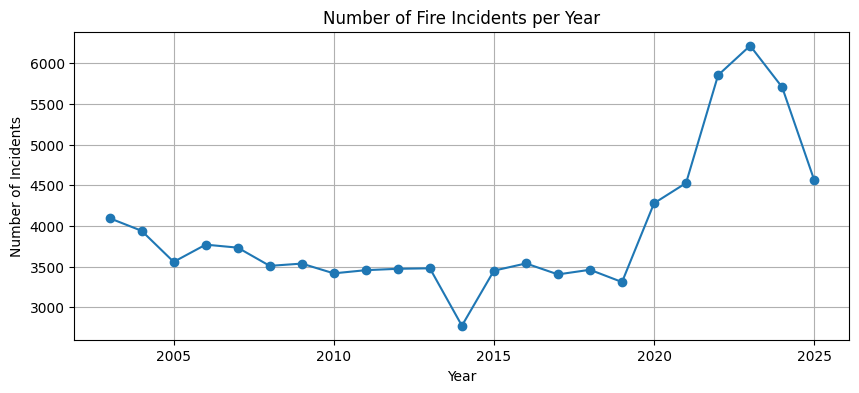

In [8]:
# Exploratory Data Analysis (EDA): Line plot of number of fire incidents per year
incidents_per_year = gdf_clean['year'].value_counts().sort_index()
plt.figure(figsize=(10,4))
plt.plot(incidents_per_year.index, incidents_per_year.values, marker='o')
plt.title('Number of Fire Incidents per Year')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.grid(True)
plt.show()

### Interactive Map of San Francisco Fire Stations

This interactive map displays the locations of all San Francisco fire department facilities using custom fire station icons. Each marker provides a popup with the station's name and address. The map is centered on San Francisco and helps visualize the spatial distribution of emergency response resources across the city. Use this map to explore where fire stations are located relative to neighborhoods and incident hotspots.


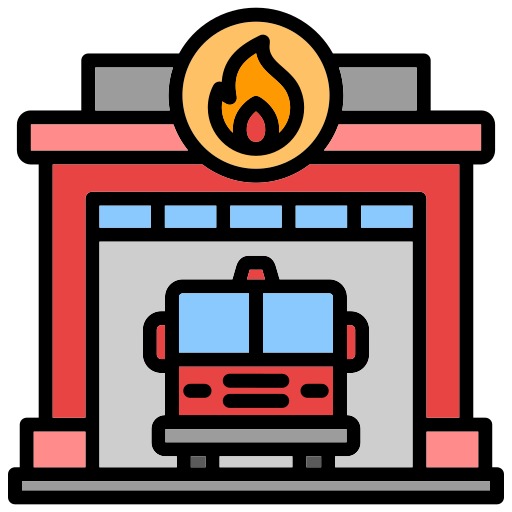

In [9]:
# Create a Folium map centered on San Francisco
sf_center_coords = [37.77, -122.42]
sf_map = folium.Map(location=sf_center_coords, zoom_start=12)

# Use a custom fire station icon
from folium.features import CustomIcon
fire_station_icon = CustomIcon('images/fire-station.png', icon_size=(30, 30))

# Add markers for each fire department facility with descriptive popup
for _, facility in fire_dept_map.iterrows():
    folium.Marker(
        location=[facility['latitude'], facility['longitude']],
        popup=f"{facility['common_name']}<br>{facility['address']}",
        icon=fire_station_icon
    ).add_to(sf_map)

# Export the map as HTML
sf_map.save('fire_stations_map.html')
sf_map

# Step 5: Feature Engineering
• Generate features from geospatial data, such as:
- Distances to specific landmarks (e.g., roads, rivers, schools).
- Area sizes, population density, or terrain attributes.
• Use these features for machine learning.
Deliverable: Final dataset with engineered features.

### Feature Engineering: Calculating Distance to Nearest Fire Station

This cell computes a new feature for each fire incident: the distance to the nearest fire station. By projecting both incidents and fire station locations to a metric coordinate system, it accurately calculates the minimum distance from each incident to any fire station in meters. This engineered feature is important for understanding how proximity to emergency resources may influence fire risk and will be used as an input for subsequent machine learning modeling.

In [10]:
# Feature Engineering: Compute distance from each true fire incident to nearest fire station
import pandas as pd
import geopandas as gpd
import numpy as np

# Use cleaned and filtered true fire incidents from Cell 3
gdf_incidents = gdf_clean.copy()

df_facilities = pd.read_csv('City_Facilities_20251209.csv', low_memory=False)
fire_dept = df_facilities[df_facilities['jurisdiction'].str.contains('Fire', case=False, na=False) | df_facilities['common_name'].str.contains('Fire', case=False, na=False)]
fire_dept = fire_dept.dropna(subset=['longitude', 'latitude'])
gdf_fire = gpd.GeoDataFrame(fire_dept, geometry=gpd.points_from_xy(fire_dept['longitude'], fire_dept['latitude']), crs='EPSG:4326')

# Project to a metric CRS for accurate distance calculation
gdf_incidents = gdf_incidents.to_crs(epsg=3857)
gdf_fire = gdf_fire.to_crs(epsg=3857)


# Calculate distance to nearest fire station for each incident
gdf_incidents['dist_to_fire_station_m'] = gdf_incidents.geometry.apply(lambda x: gdf_fire.distance(x).min())


# Drop any rows with NaN in key columns to avoid issues in modeling
gdf_incidents = gdf_incidents.dropna(subset=['dist_to_fire_station_m', 'Supervisor District'])

# Show the first few rows of the engineered features
gdf_incidents[['Address', 'Primary Situation', 'dist_to_fire_station_m']]

,Address,Primary Situation,dist_to_fire_station_m
12,205 9TH STREET,"113 Cooking fire, confined to container",934.558676
18,666 POST STREET,"118 Trash or rubbish fire, contained",341.469400
19,SILVER AVENUE,"151 Outside rubbish, trash or waste fire",210.045714
20,GILMAN AVENUE,"151 Outside rubbish, trash or waste fire",1865.624825
22,17TH STREET,"150 Outside rubbish fire, other",730.103052
...,...,...,...
726320,155 DIVISADERO STREET,"113 Cooking fire, confined to container",532.660951
726334,300 BLK ELIZABETH STREET,131 Passenger vehicle fire,528.807632
726348,40 VEGA STREET,"100 Fire, other",718.091236
726371,1880 STEINER STREET,"100 Fire, other",717.305980


### Classifying and Visualizing Fire Risk by District

This cell assigns a fire risk level (Low, Medium, High) to each supervisor district based on the density of fire incidents using quantile-based classification. It merges these risk levels with the district boundaries and visualizes the results as a choropleth map. This step helps identify which areas of San Francisco are at higher risk for fires, providing valuable insights for emergency planning and resource allocation.

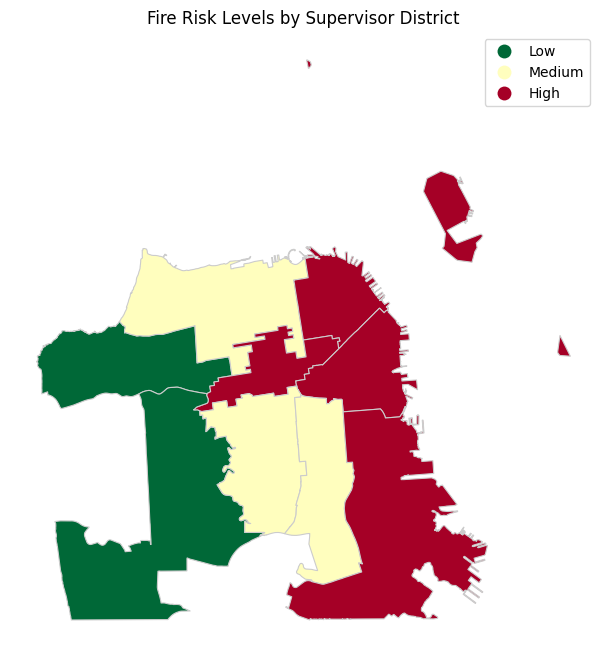

In [11]:
# Classify supervisor districts by fire risk level based on incident density (Cell 5-inspired robust workflow)
import numpy as np
import matplotlib.pyplot as plt

# Aggregate fire incidents by supervisor district, excluding Farallon Islands (11)
incidents_by_district = gdf_clean[gdf_clean['Supervisor District'] != 11].groupby('Supervisor District').size().reset_index(name='incident_count')

# Assign risk levels using quantiles
risk_labels = ['Low', 'Medium', 'High']
incidents_by_district['risk_level'] = pd.qcut(incidents_by_district['incident_count'], q=3, labels=risk_labels)

# Ensure supervisor district codes are strings
incidents_by_district['Supervisor District'] = incidents_by_district['Supervisor District'].astype(str)
sf_districts_cleaned['sup_dist_num'] = sf_districts_cleaned['sup_dist_num'].astype(str)


# Merge incident counts and risk levels with cleaned district boundaries
sf_districts_merged = sf_districts_cleaned.merge(incidents_by_district, left_on='sup_dist_num', right_on='Supervisor District', how='left')

# Filter to valid districts and remove large polygons
valid_districts = incidents_by_district['Supervisor District'].unique().tolist()
sf_districts_final = sf_districts_merged[sf_districts_merged['sup_dist_num'].isin(valid_districts)]
sf_districts_final = sf_districts_final.to_crs(epsg=3857)
sf_districts_final['area_m2'] = sf_districts_final['geometry'].area
sf_districts_final = sf_districts_final[sf_districts_final['area_m2'] < 5e7]

# Plot robust cleaned choropleth map by risk level
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
sf_districts_final.plot(column='risk_level', cmap='RdYlGn_r', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Fire Risk Levels by Supervisor District')
ax.axis('off')
plt.show()

### Merging District Risk Levels with Incident Data

This cell enriches each fire incident record by merging the corresponding supervisor district's risk level into the incident-level dataset. This step finalizes the feature engineering process, ensuring that each incident now includes both its distance to the nearest fire station and the overall fire risk classification of its district. The resulting dataset is ready for use in machine learning modeling to predict fire risk.

In [12]:
# Merge district risk level onto each incident and prepare for incident-level modeling
gdf_incidents['Supervisor District'] = gdf_incidents['Supervisor District'].astype(str)
incidents_by_district['Supervisor District'] = incidents_by_district['Supervisor District'].astype(str)
incidents_by_district_risk = incidents_by_district[['Supervisor District', 'risk_level']].copy()
gdf_incidents = gdf_incidents.merge(incidents_by_district_risk, on='Supervisor District', how='left')
print('Incident-level DataFrame with risk level:')
print(gdf_incidents[['Address', 'Supervisor District', 'dist_to_fire_station_m', 'risk_level']].head())
print('\nRisk level value counts:')
print(gdf_incidents['risk_level'].value_counts())

Incident-level DataFrame with risk level:
           Address Supervisor District  dist_to_fire_station_m risk_level
0   205 9TH STREET                 6.0              934.558676       High
1  666 POST STREET                 3.0              341.469400       High
2    SILVER AVENUE                 9.0              210.045714     Medium
3    GILMAN AVENUE                10.0             1865.624825       High
4      17TH STREET                 8.0              730.103052     Medium

Risk level value counts:
risk_level
High      55221
Medium    22805
Low       12354
Name: count, dtype: int64


In [13]:
# Export the feature-engineered dataset for modeling
gdf_incidents.drop(columns='geometry').to_csv('feature_engineered_fire_incidents.csv', index=False)

# Step 7: Visualization Using Folium
• Visualize your results on an interactive map:
- Use Folium to plot predictions or clusters.
- Add relevant layers (e.g., roads, rivers, buildings).
Deliverable: An interactive map in HTML format.


### Interactive Map: Visualizing Predicted Fire Risk and Emergency Resources

This cell creates an interactive Folium map that visualizes fire incidents across San Francisco by their predicted risk level. The map includes:
- Colored and clustered markers for each incident, with detailed popups showing address, risk, and district information.
- Supervisor district boundaries as overlays for spatial context.
- Custom fire station icons to highlight emergency resource locations.
- A custom legend to help interpret the map's colors and symbols.

The map is saved as an HTML file and serves as a key deliverable, providing an intuitive, interactive way to explore fire risk and emergency response coverage in the city.

In [17]:
# Import incident-level predictions for visualization
incident_predictions_df = pd.read_csv('incident_predictions_with_risk.csv')
incident_predictions_df.point

0        POINT (-122.397404 37.792469)
1        POINT (-122.421406 37.781386)
2         POINT (-122.409503 37.76561)
3        POINT (-122.411244 37.784271)
4        POINT (-122.405445 37.796244)
                     ...              
27109    POINT (-122.480599 37.717531)
27110    POINT (-122.443171 37.756217)
27111    POINT (-122.391621 37.774447)
27112     POINT (-122.398008 37.71903)
27113    POINT (-122.432375 37.778623)
Name: point, Length: 27114, dtype: object

In [18]:
from shapely import wkt

incident_predictions_df['geometry'] = incident_predictions_df['point'].apply(wkt.loads)
incident_predictions_df['lon'] = incident_predictions_df['geometry'].apply(lambda p: p.x)
incident_predictions_df['lat'] = incident_predictions_df['geometry'].apply(lambda p: p.y)

In [25]:
import folium
from folium.plugins import MarkerCluster

risk_colors = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}

m = folium.Map(location=[37.77, -122.42], zoom_start=12)
marker_cluster = MarkerCluster().add_to(m)

districts_gdf = sf_districts_cleaned.to_crs(epsg=4326).copy()
cols_to_keep = [col for col in districts_gdf.columns if not pd.api.types.is_datetime64_any_dtype(districts_gdf[col])]
districts_gdf = districts_gdf[cols_to_keep]
folium.GeoJson(
    data=json.loads(districts_gdf.to_json()),
    name='Supervisor Districts',
    style_function=lambda feature: {
        'fillColor': '#00000000',
        'color': 'blue',
        'weight': 2,
        'fillOpacity': 0.0
    },
    tooltip=folium.GeoJsonTooltip(fields=['sup_dist_num'], aliases=['Supervisor District:'])
).add_to(m)

incidents_by_district['Supervisor District'] = incidents_by_district['Supervisor District'].astype(str)
district_incident_count = incidents_by_district.set_index('Supervisor District')['incident_count'].to_dict()

for _, row in incident_predictions_df.iterrows():
    district = str(row['Supervisor District'])
    incident_count = district_incident_count.get(district, 'N/A')
    risk_color = risk_colors.get(row['risk_level'], 'blue')
    popup_html = f'''
    <div style="width: 600px; font-size: 14px;">
        <b>Address:</b> {row['Address']}<br>
        <b>Neighborhood:</b> {row['neighborhood_district']}<br>
        <b>Supervisor District:</b> {row['Supervisor District']}<br>
        <b>Primary Situation:</b> {row['Primary Situation']}<br>
        <b>District Amount of Fire Incidents:</b> <span style="color:{risk_color};font-weight:bold;">{incident_count}</span><br>
        <b>Risk Level of District Based on Amount of Incidents:</b> <span style="font-weight:bold;color:{risk_color}">{row['risk_level']}</span><br>
        <b>Distance to Nearest Fire Station:</b> {row['dist_to_fire_station_m']:.1f} meters<br>
        <b>Predicted Risk Based on Risk Level and <br>Distance to Nearest Fire Station:</b> <span style="font-weight:bold;color:{risk_colors.get(row['predicted_risk_level'], 'blue')}">{row['predicted_risk_level']}</span><br>
    </div>
    '''
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=10,
        color=risk_colors.get(row['predicted_risk_level'], 'blue'),
        fill=True,
        fill_color=risk_colors.get(row['predicted_risk_level'], 'blue'),
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=450)
    ).add_to(marker_cluster)

from folium.features import CustomIcon
fire_station_icon = CustomIcon('images/fire-station.png', icon_size=(30, 30))
for _, row in fire_dept_map.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        icon=fire_station_icon,
        tooltip='Fire Station'
    ).add_to(m)

legend_html = '''
<div style='position: fixed; bottom: 50px; left: 50px; width: 230px; height: 150px;
     border:2px solid grey; z-index:9999; font-size:14px; background-color:white;'>
&nbsp;<b>Predicted Risk Level</b><br>
&nbsp;<i class="fa fa-circle" style="color:red"></i>&nbsp;High<br>
&nbsp;<i class="fa fa-circle" style="color:orange"></i>&nbsp;Medium<br>
&nbsp;<i class="fa fa-circle" style="color:green"></i>&nbsp;Low<br>
&nbsp;<span style='color:blue;'>Blue Border</span>: Supervisor District<br>
&nbsp;<img src='images/fire-station.png' style='height:20px;vertical-align:middle;'> Fire Station<br>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

m.save('fire_incidents_predicted_risk_map.html')